### PCA Analysis
This notebook is used to carry out the PCA analysis for the first ML project. The analysis addresses the following aspects (from project description):
- The principal directions of the considered PCA components. Plot and interpret the components in terms of the attributes.
- The amount of variance explained as a function of the number of PCA components included.
- The data projected onto the considered principal components, e.g. in 2D scatter plots.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Plotting style
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.5)

Loading the heart disease dataset and selecting only the continuous variables:

In [56]:
df = pd.read_csv("data/heartDisease.csv")
X = df.drop(labels=["row.names", "famhist", "chd"], axis=1)
y = df.loc[:, "chd"]

Standardizing the data:

In [57]:
scaler = StandardScaler()
X_tilde = scaler.fit_transform(X)

Obtaining the principal components by fitting the PCA to the data:

In [58]:
pca = PCA()
pca.fit(X_tilde)
V = pca.components_.T

Plotting the PCA component coefficients for the first 3 principal components:

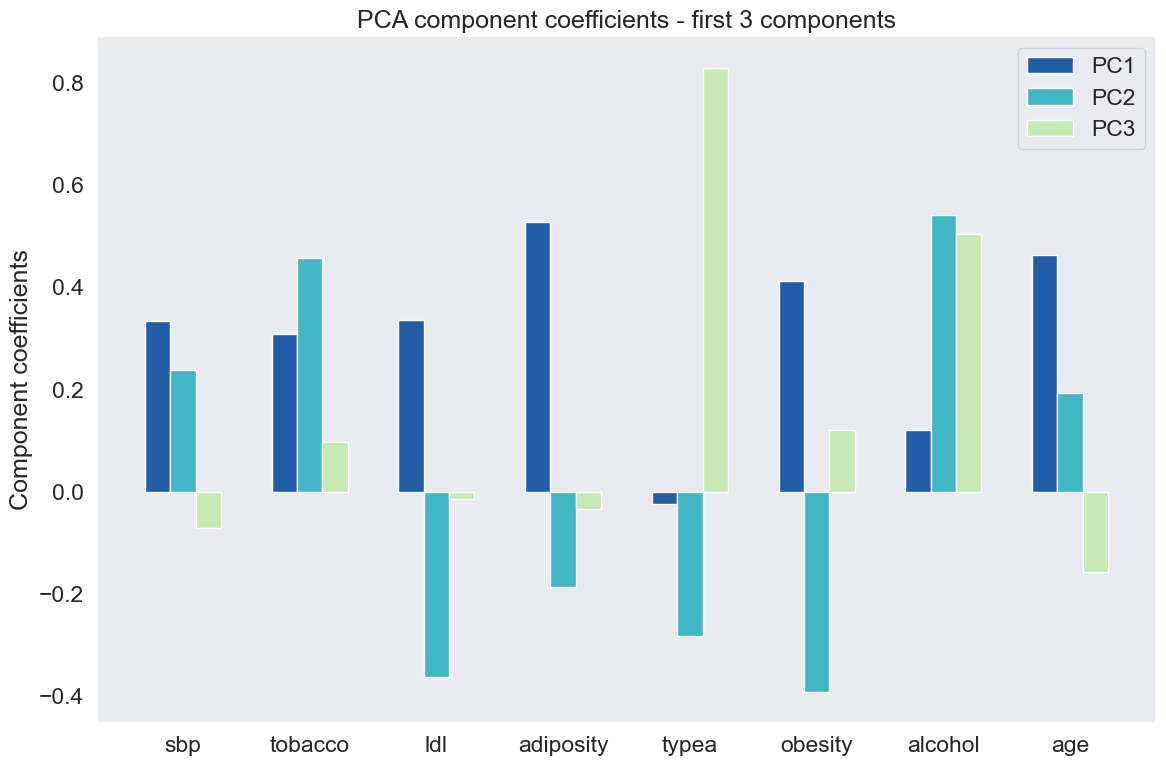

In [59]:
bw = 0.2
r = np.arange(1, X.shape[1] + 1)
n_components = 3
colors = ['#225ea8', '#41b6c4', '#c7e9b4']

fig = plt.figure(figsize=(12, 8))
plt.title(f"PCA component coefficients - first {n_components} components")

for i, pc in enumerate(V[:, :n_components].T):
    color = colors[i] if i < len(colors) else None
    plt.bar(r + i * bw, pc, width=bw, label=f"PC{i+1}", color=color)
    
plt.xticks(r + bw, X.columns)
plt.ylabel("Component coefficients")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Plotting the attribute coefficients in PC1/PC2-space:

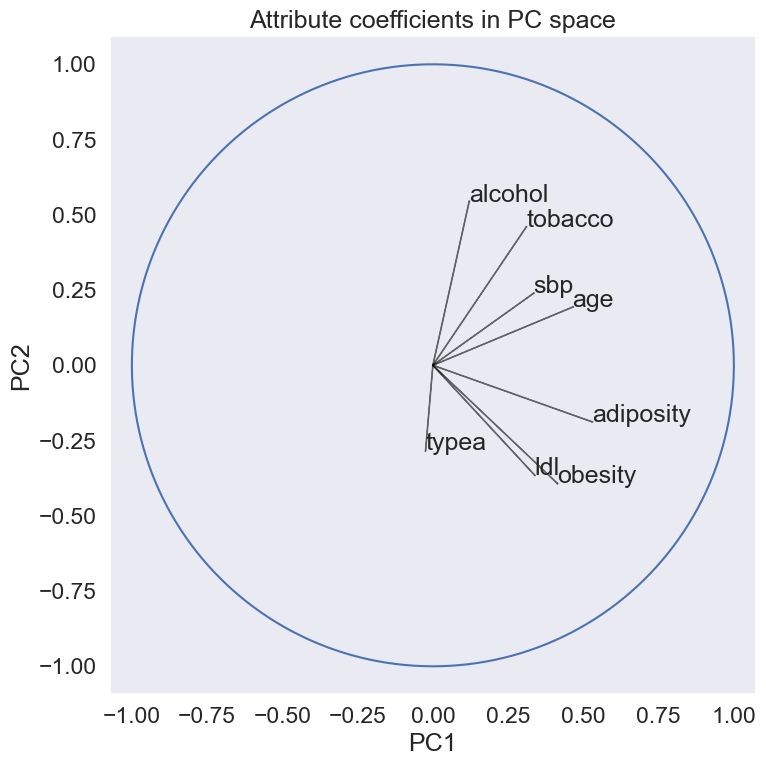

In [60]:
PC_idxs = [0, 1]
fig = plt.figure(figsize=(8, 8))
plt.title("Attribute coefficients in PC space")

for attr_idx, attr_name in enumerate(X.columns):
    plt.arrow(0, 0, V[attr_idx, PC_idxs[0]], V[attr_idx, PC_idxs[1]], color='black', alpha=0.5)
    plt.text(V[attr_idx, PC_idxs[0]], V[attr_idx, PC_idxs[1]], attr_name)
    
plt.xlabel(f"PC{PC_idxs[0] + 1}")
plt.ylabel(f"PC{PC_idxs[1] + 1}")
plt.grid()

# unit circle
plt.plot(np.cos(np.arange(0, 2 * np.pi, 0.01)), np.sin(np.arange(0, 2 * np.pi, 0.01)))
plt.axis("equal")
plt.tight_layout()

Plotting the explained variance for each principal component and accumulated: 

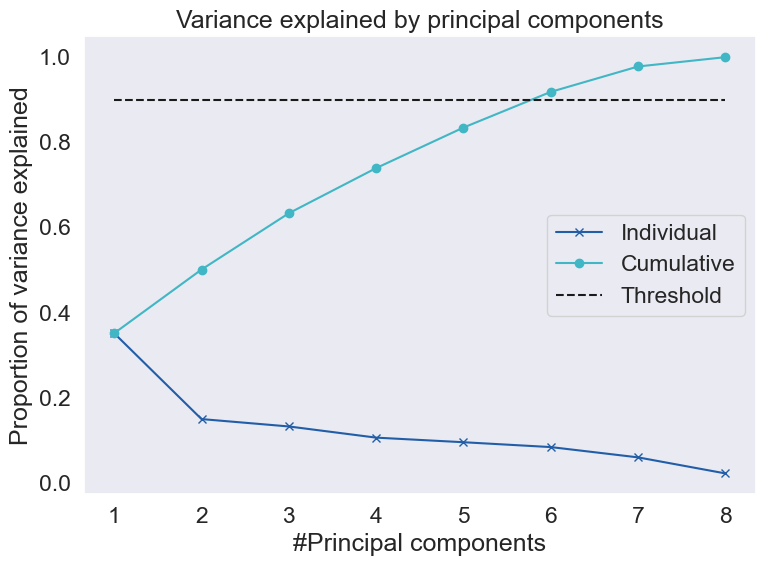

In [61]:
rho = pca.explained_variance_ratio_
threshold = 0.9

fig = plt.figure(figsize=(8, 6))

# individual proportion of variance explained
plt.plot(range(1, len(rho) + 1), rho, "x-", color="#225ea8")

# accumulated proportion of variance explained
plt.plot(range(1, len(rho) + 1), np.cumsum(rho), "o-", color="#41b6c4")

# threshold
plt.plot([1, len(rho)], [threshold, threshold], "k--")

plt.title("Variance explained by principal components")
plt.xlabel("#Principal components")
plt.ylabel("Proportion of variance explained")
plt.legend(["Individual", "Cumulative", "Threshold"])
plt.grid()
plt.tight_layout()
plt.show()

Projecting the data onto the PC1/PC2 space and plotting it as a scatter encoded by `chd`:

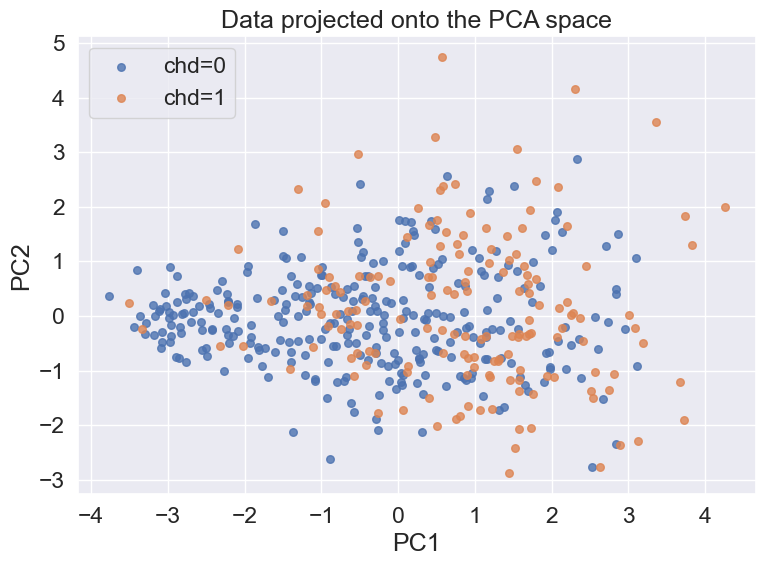

In [62]:
# projecting onto the PCA subspace
B = pca.transform(X_tilde)
unique_classes = np.unique(y)

fig = plt.figure(figsize=(8, 6))
plt.title("Data projected onto the PCA space")

for chd_val in unique_classes:
    mask = (y == chd_val)
    plt.scatter(B[mask, PC_idxs[0]], B[mask, PC_idxs[1]], s=30, alpha=0.8, label=f"chd={chd_val}")

plt.xlabel(f"PC{PC_idxs[0] + 1}")
plt.ylabel(f"PC{PC_idxs[1] + 1}")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()